# Notebook 05 — SHAP & Interprétabilité du modèle SWRO

**PFE — Master Science des Données**

### Objectif
Interpréter le **modèle MLP optimisé** obtenu dans le Notebook 04 et identifier les variables qui influencent le plus la consommation énergétique spécifique (**SEC, kWh/m³**).

> Le notebook utilise le modèle déjà entraîné. Il ne réentraîne pas le modèle.

In [2]:
# 0. Imports
# Si SHAP n'est pas installé, exécutez dans une cellule :
# %pip install shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

try:
    import shap
except ImportError:
    raise ImportError("SHAP n'est pas installé. Exécutez : %pip install shap")

print("SHAP :", shap.__version__)

SHAP : 0.49.1


C:\Users\UltraPc\anaconda3\envs\new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# 1. Configuration
DATA_DIR = Path("data/preprocessed")
MODEL_DIR = Path("models")
RESULT_DIR = Path("results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "best_model_optimized.pkl"

FEATURES = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]

print("Modèle :", MODEL_PATH.resolve())

Modèle : C:\Users\UltraPc\Documents\pfe\code\models\best_model_optimized.pkl


In [4]:
# 2. Charger le modèle final
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Modèle introuvable : {MODEL_PATH}. "
        "Exécutez d'abord le Notebook 04 corrigé."
    )

model = joblib.load(MODEL_PATH)
print("Modèle chargé :", type(model).__name__)

Modèle chargé : MLPRegressor


## 3. Charger les données

Nous utilisons le jeu de test pour l'interprétation finale. Les mêmes colonnes et le même prétraitement que dans les notebooks précédents doivent être conservés.

In [5]:
# 3. Données
X_train = pd.read_csv(DATA_DIR / "X_train_scaled.csv")
X_val = pd.read_csv(DATA_DIR / "X_val_scaled.csv")
X_test = pd.read_csv(DATA_DIR / "X_test_scaled.csv")

y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze("columns")
y_val = pd.read_csv(DATA_DIR / "y_val.csv").squeeze("columns")
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze("columns")

# Vérification des variables
missing = [f for f in FEATURES if f not in X_test.columns]
if missing:
    raise ValueError(f"Variables absentes de X_test : {missing}")

X_test = X_test[FEATURES]
X_train = X_train[FEATURES]

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("Variables :", FEATURES)

X_train : (7000, 8)
X_test  : (1500, 8)
Variables : ['pressure_bar', 'feed_flow_m3_h', 'salinity_g_L', 'temperature_C', 'recovery_rate_target', 'pump_efficiency', 'erd_efficiency', 'membrane_condition']


In [6]:
# 4. Vérification des prédictions
y_pred_test = model.predict(X_test)

print("Prédictions :", len(y_pred_test))
print("SEC prédite min/max :", y_pred_test.min(), "/", y_pred_test.max())

assert len(y_pred_test) == len(y_test)
assert np.isfinite(y_pred_test).all()

Prédictions : 1500
SEC prédite min/max : 2.413422134656596 / 5.217742932289078


# 5. Échantillon SHAP

Pour un MLP, SHAP peut être coûteux. Nous utilisons un échantillon du train comme **background** et une partie du test pour l'explication.

In [7]:
BACKGROUND_SIZE = min(200, len(X_train))
EXPLAIN_SIZE = min(500, len(X_test))

background = X_train.sample(
    BACKGROUND_SIZE,
    random_state=42
)

X_explain = X_test.sample(
    EXPLAIN_SIZE,
    random_state=42
)

y_explain = y_test.loc[X_explain.index]

print("Background :", background.shape)
print("À expliquer :", X_explain.shape)

Background : (200, 8)
À expliquer : (500, 8)


# 6. Création de l'explainer SHAP

Pour le MLP, nous utilisons `shap.Explainer` avec une fonction de prédiction et un background représentatif.

In [8]:
explainer = shap.Explainer(
    model.predict,
    background
)

print("Explainer :", type(explainer).__name__)

Explainer : ExactExplainer


# 7. Calcul des valeurs SHAP

Cette cellule peut prendre quelques minutes selon la machine.

In [9]:
shap_result = explainer(X_explain)

shap_values = shap_result.values

# Pour une régression, SHAP doit avoir :
# nombre_observations x nombre_variables
if shap_values.ndim != 2:
    raise ValueError(
        f"Forme SHAP inattendue : {shap_values.shape}"
    )

print("SHAP shape :", shap_values.shape)
print("X shape    :", X_explain.shape)

ExactExplainer explainer: 501it [00:46,  9.83it/s]                         

SHAP shape : (500, 8)
X shape    : (500, 8)


# 8. Importance globale

`Mean |SHAP|` mesure l'influence moyenne absolue de chaque variable sur les prédictions.

,Feature,Mean_Abs_SHAP,Relative_Importance_%
0,pump_efficiency,0.249367,30.450607
1,recovery_rate_target,0.240656,29.386829
2,pressure_bar,0.216009,26.377221
3,erd_efficiency,0.094303,11.515524
4,salinity_g_L,0.005622,0.686539
5,temperature_C,0.004625,0.564792
6,feed_flow_m3_h,0.004348,0.530922
7,membrane_condition,0.003993,0.487566


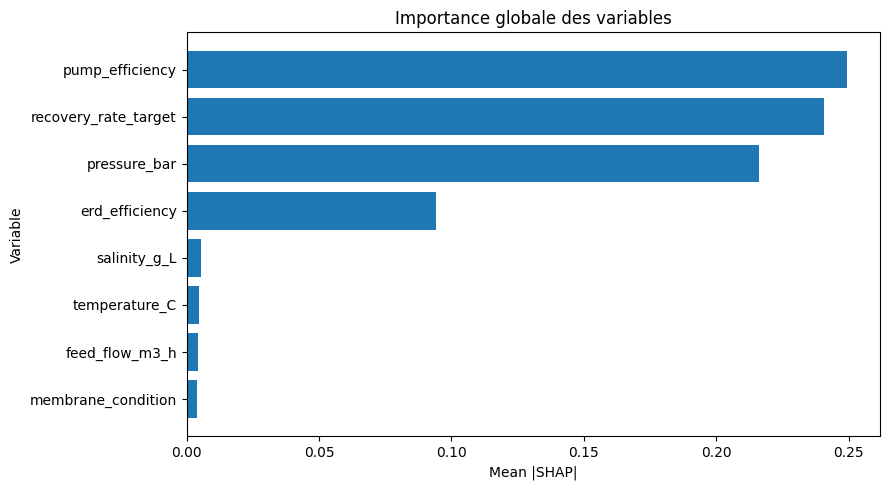

In [10]:
global_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
).reset_index(drop=True)

global_importance["Relative_Importance_%"] = (
    global_importance["Mean_Abs_SHAP"]
    / global_importance["Mean_Abs_SHAP"].sum()
    * 100
)

display(global_importance)

plt.figure(figsize=(9, 5))
plt.barh(
    global_importance["Feature"][::-1],
    global_importance["Mean_Abs_SHAP"][::-1]
)
plt.xlabel("Mean |SHAP|")
plt.ylabel("Variable")
plt.title("Importance globale des variables")
plt.tight_layout()
plt.show()

# 9. SHAP Summary Plot

Ce graphique montre simultanément l'importance, la dispersion des contributions et le sens de l'effet.

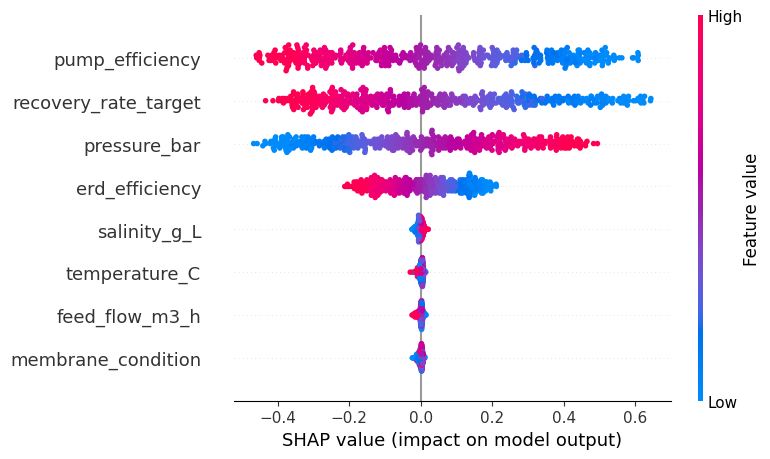

In [11]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=FEATURES,
    show=True
)

# 10. SHAP Bar Plot

Vue simplifiée de l'importance globale.

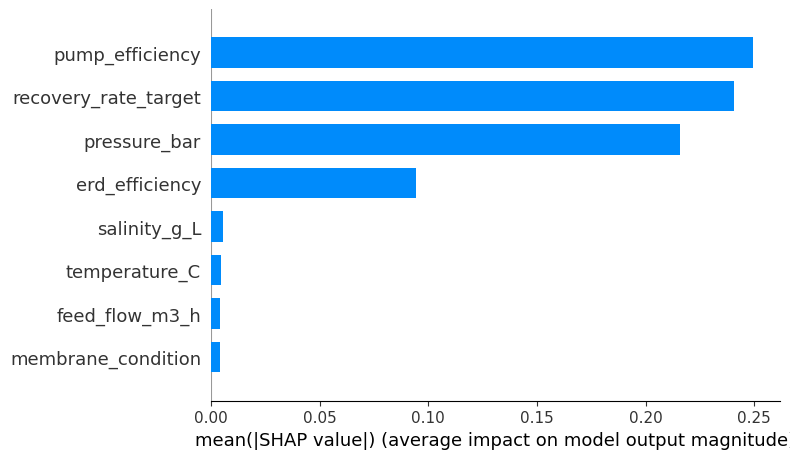

In [12]:
shap.summary_plot(
    shap_values,
    X_explain,
    feature_names=FEATURES,
    plot_type="bar",
    show=True
)

# 11. Importance signée

La moyenne SHAP indique la tendance globale de contribution.

**Attention :** une moyenne proche de zéro ne signifie pas qu'une variable est sans importance ; des effets positifs et négatifs peuvent se compenser.

In [13]:
signed_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Mean_SHAP": shap_values.mean(axis=0),
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

display(signed_importance)

,Feature,Mean_SHAP,Mean_Abs_SHAP
5,pump_efficiency,0.040886,0.249367
4,recovery_rate_target,0.044789,0.240656
0,pressure_bar,0.015710,0.216009
6,erd_efficiency,0.004275,0.094303
2,salinity_g_L,-0.001202,0.005622
3,temperature_C,0.000930,0.004625
1,feed_flow_m3_h,-0.000220,0.004348
7,membrane_condition,-0.000300,0.003993


# 12. Dépendance SHAP

Pour chaque variable, on observe comment sa valeur est associée à sa contribution au modèle.

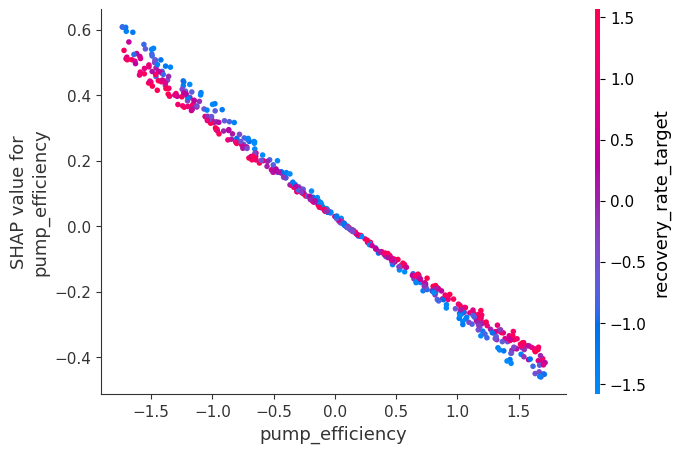

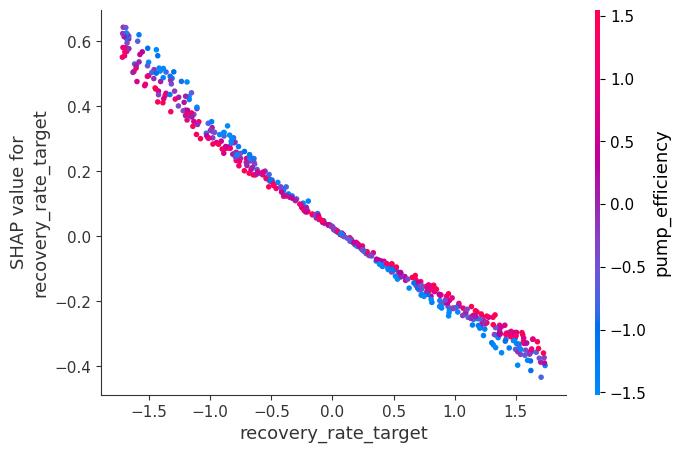

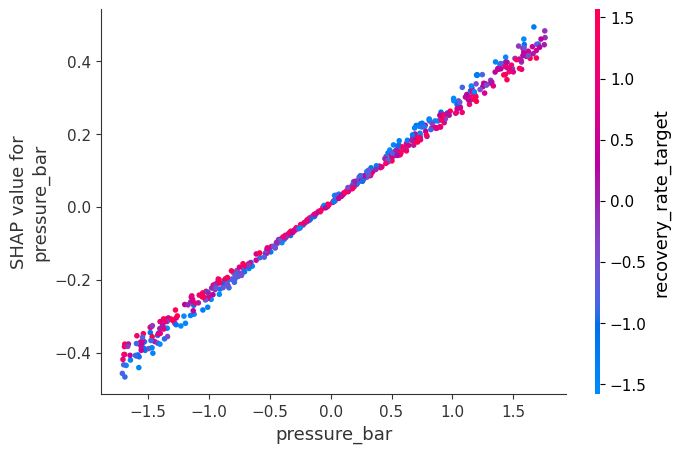

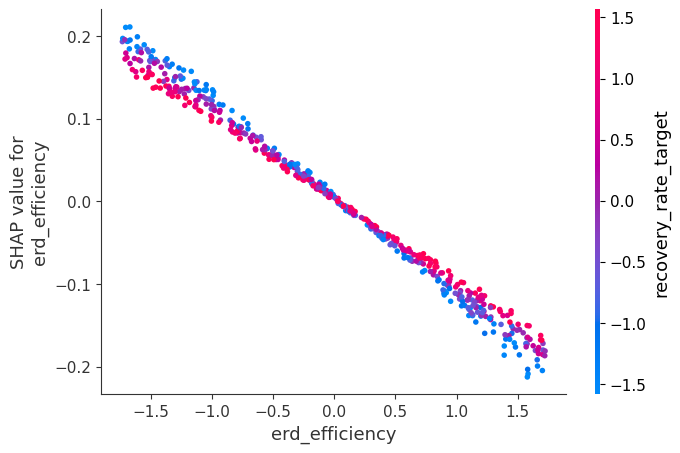

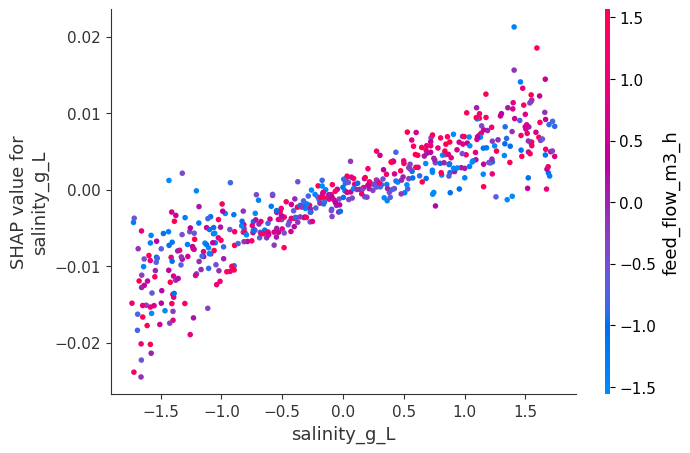

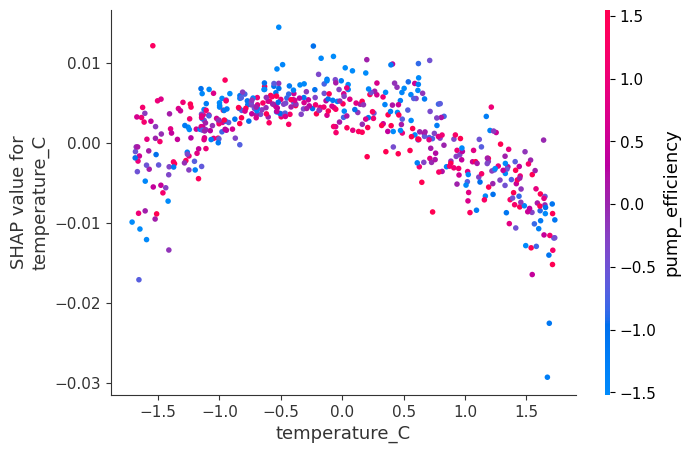

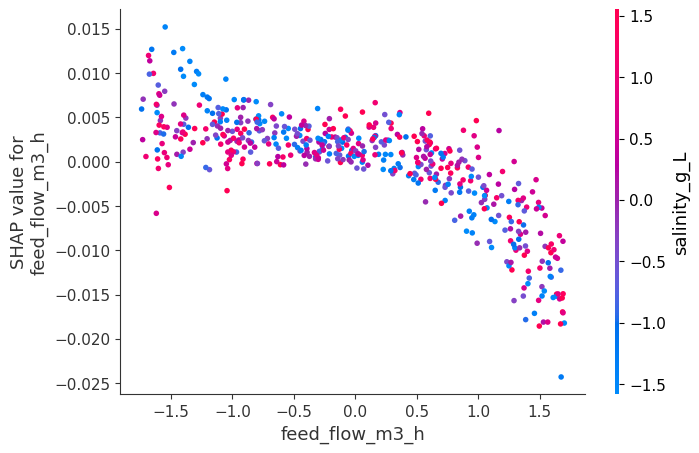

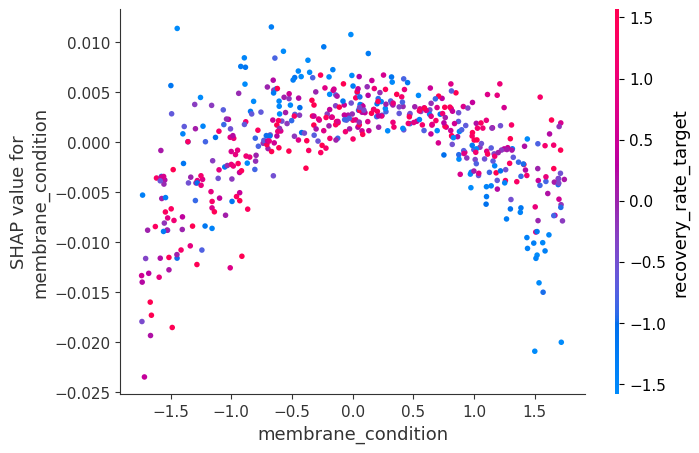

In [14]:
for feature in global_importance["Feature"]:
    shap.dependence_plot(
        feature,
        shap_values,
        X_explain,
        feature_names=FEATURES,
        show=True
    )

# 13. Explication d'une prédiction individuelle

Le waterfall plot explique pourquoi une observation donnée reçoit sa prédiction.

In [15]:
# Observation la plus proche de la médiane de SEC prédite
sample_position = int(
    np.argsort(y_explain.values)[len(y_explain) // 2]
)

single = shap_values[sample_position]
x_one = X_explain.iloc[[sample_position]]

pred_one = model.predict(x_one)[0]
real_one = y_explain.iloc[sample_position]

print(f"SEC réelle   : {real_one:.6f} kWh/m³")
print(f"SEC prédite  : {pred_one:.6f} kWh/m³")

individual_table = pd.DataFrame({
    "Feature": FEATURES,
    "Value": x_one.iloc[0].values,
    "SHAP": single
}).sort_values(
    "SHAP",
    key=np.abs,
    ascending=False
)

display(individual_table)

SEC réelle   : 3.560283 kWh/m³
SEC prédite  : 3.665504 kWh/m³


,Feature,Value,SHAP
5,pump_efficiency,1.441705,-0.386591
0,pressure_bar,1.279517,0.334273
4,recovery_rate_target,-0.481734,0.157356
6,erd_efficiency,-0.638611,0.077732
3,temperature_C,1.445534,-0.008028
2,salinity_g_L,-1.122196,-0.007195
1,feed_flow_m3_h,-1.189318,0.007132
7,membrane_condition,1.303844,-0.005717


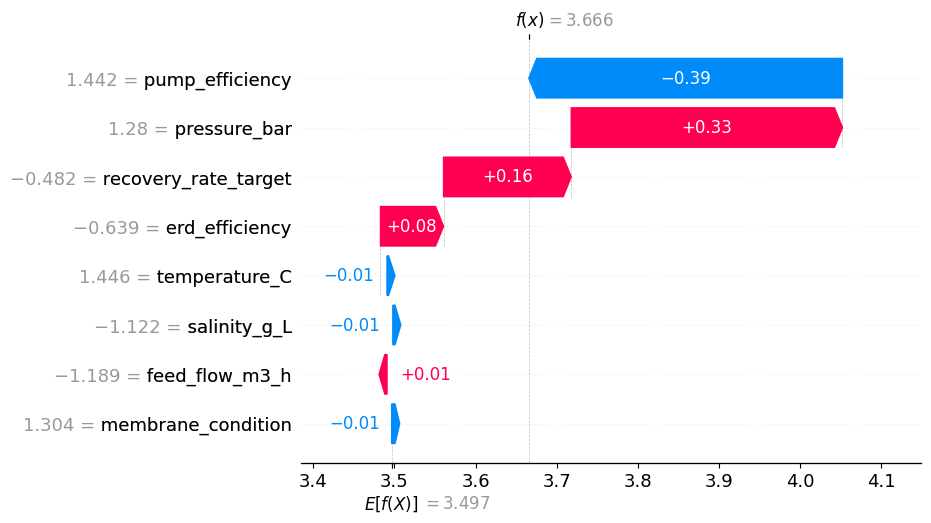

In [16]:
# Waterfall
base_value = float(np.asarray(shap_result.base_values[sample_position]).reshape(-1)[0])

explanation = shap.Explanation(
    values=single,
    base_values=base_value,
    data=x_one.iloc[0].values,
    feature_names=FEATURES
)

shap.plots.waterfall(
    explanation,
    max_display=len(FEATURES)
)

# 14. Plusieurs prédictions individuelles

Nous examinons plusieurs observations afin d'éviter une conclusion basée sur un seul cas.

Observation 0 — réelle = 3.9300, prédite = 3.8368


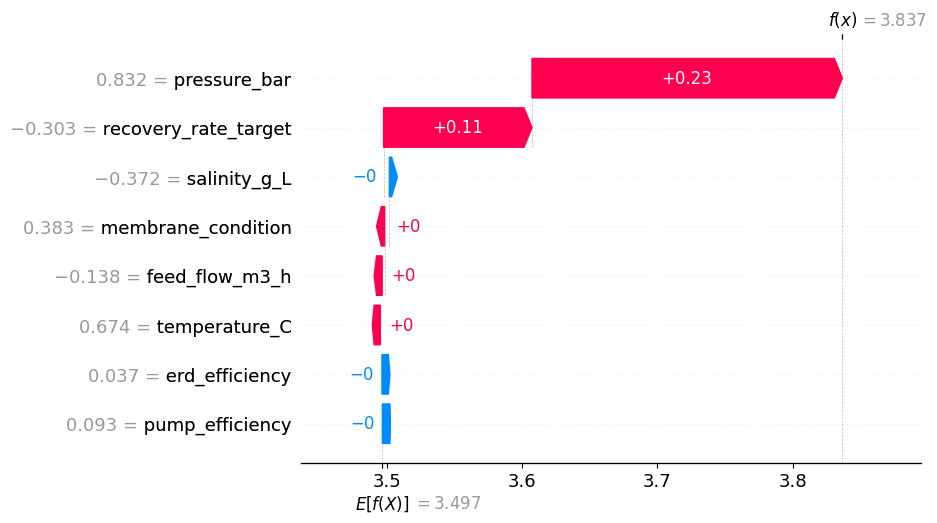

Observation 1 — réelle = 3.6017, prédite = 3.7913


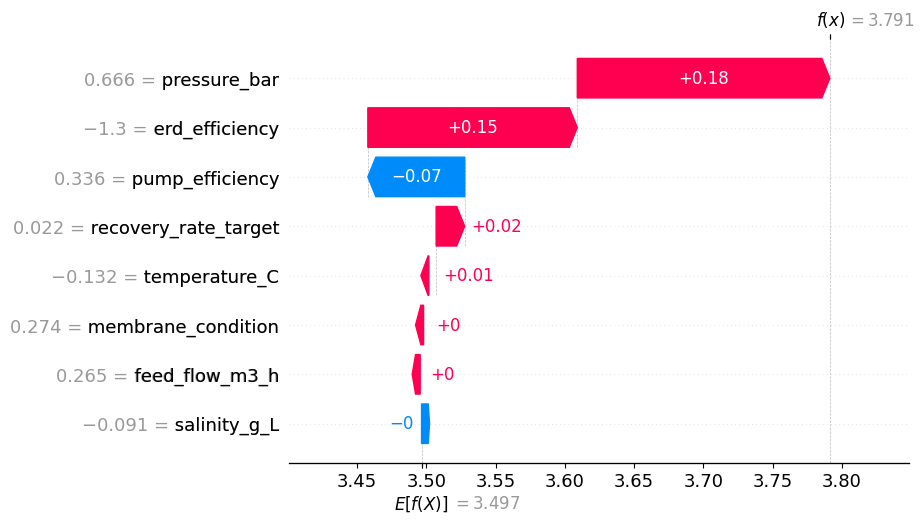

Observation 2 — réelle = 3.6552, prédite = 3.3866


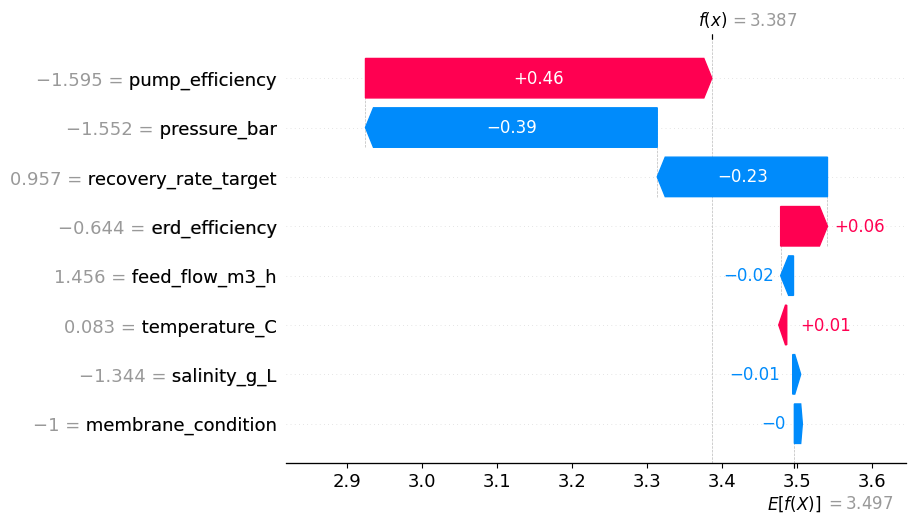

In [17]:
n_examples = min(3, len(X_explain))

for i in range(n_examples):
    pred = model.predict(X_explain.iloc[[i]])[0]
    real = y_explain.iloc[i]

    print(
        f"Observation {i} — "
        f"réelle = {real:.4f}, prédite = {pred:.4f}"
    )

    base_i = float(
        np.asarray(shap_result.base_values[i]).reshape(-1)[0]
    )

    exp_i = shap.Explanation(
        values=shap_values[i],
        base_values=base_i,
        data=X_explain.iloc[i].values,
        feature_names=FEATURES
    )

    shap.plots.waterfall(exp_i, max_display=8)

# 15. Export des résultats

Les fichiers pourront être utilisés dans le mémoire et dans le futur dashboard.

In [18]:
# Importance globale
global_importance.to_csv(
    RESULT_DIR / "shap_global_importance.csv",
    index=False
)

# Importance signée
signed_importance.to_csv(
    RESULT_DIR / "shap_signed_importance.csv",
    index=False
)

# Valeurs SHAP
pd.DataFrame(
    shap_values,
    columns=FEATURES,
    index=X_explain.index
).to_csv(
    RESULT_DIR / "shap_values_test_sample.csv"
)

# Observations expliquées
explained = X_explain.copy()
explained["SEC_real"] = y_explain.values
explained["SEC_pred"] = model.predict(X_explain)

explained.to_csv(
    RESULT_DIR / "shap_explained_observations.csv"
)

print("Résultats SHAP sauvegardés dans :", RESULT_DIR.resolve())

Résultats SHAP sauvegardés dans : C:\Users\UltraPc\Documents\pfe\code\results


# 16. Conclusion à compléter après exécution

Après exécution, relever dans le mémoire :

1. les 3 à 5 variables ayant le plus grand `Mean |SHAP|` ;
2. le sens de leur influence à partir du Summary Plot et des Dependence Plots ;
3. un ou deux exemples de prédictions expliquées par Waterfall Plot.

### Limitation

SHAP explique **le comportement du modèle**. Il ne démontre pas à lui seul une causalité physique.

La prochaine étape sera :

**Notebook 06 — Optimisation énergétique**

Nous chercherons des conditions de fonctionnement donnant une SEC minimale tout en respectant les contraintes physiques du système SWRO.